# TCR–peptide ranking with peptide features, TCR features, and TCRen

This notebook gives an overview of the project and its main results.

## Goal
The goal of this project was to test whether simple engineered features can help rank candidate peptides for a given T cell receptor (TCR), and to compare these models with the structure-based TCRen baseline.

## What was done
Starting from the data released with the TCRen paper, I:

- built candidate peptide sets for individual TCR systems
- computed TCRen scores for each candidate peptide
- engineered peptide-derived features
- engineered TCR-derived features from CDR3α and CDR3β
- compared several models using repeated grouped train/test splits

## Models compared
- **TCRen baseline**
- **LogReg peptide**
- **RF peptide**
- **LogReg peptide+TCR**
- **RF peptide+TCR**
- **LogReg full**
- **RF full**

Here, **full** means:
- peptide features
- TCR features
- TCRen score

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
base = Path("../results")

results_csv = base / "repeated_eval_all_results_with_tcr.csv"
summary_csv = base / "repeated_eval_summary_with_tcr.csv"

results = pd.read_csv(results_csv)
summary = pd.read_csv(summary_csv)

print("Results shape:", results.shape)
print("Summary shape:", summary.shape)

Results shape: (210, 12)
Summary shape: (7, 17)


## Evaluation setup

The models were evaluated using repeated grouped train/test splits.

### Important detail
The split was done by **`pdb_id`**, not by random rows, so all candidate peptides for the same TCR system stayed together in either the training set or the test set.

This avoids leakage and makes the evaluation more realistic.

### Metrics used
Because this is mainly a ranking task, the most useful metrics are:

- **average precision**
- **MRR** (mean reciprocal rank)
- **top-1**
- **top-5**

Note that accuracy is included, although it is less useful in this particular case, since we are dealing with a highly imbalanced dataset.

In [3]:
show_cols = [
    "model",
    "avg_precision_mean", "avg_precision_std",
    "mrr_mean", "mrr_std",
    "top1_mean", "top1_std",
    "top5_mean", "top5_std",
]

summary[show_cols].sort_values("mrr_mean", ascending=False)

,model,avg_precision_mean,avg_precision_std,mrr_mean,mrr_std,top1_mean,top1_std,top5_mean,top5_std
3,rf_full,0.493498,0.146318,0.619295,0.148923,0.495833,0.178244,0.766667,0.175962
0,logreg_full,0.370765,0.122213,0.556221,0.131824,0.450000,0.159471,0.700000,0.148991
4,rf_peptide,0.354508,0.119532,0.514060,0.142618,0.383333,0.139013,0.670833,0.216465
5,rf_peptide_tcr,0.351293,0.134335,0.479375,0.143922,0.350000,0.136931,0.629167,0.195541
6,tcren_baseline,0.221983,0.110385,0.334269,0.084985,0.150000,0.095141,0.487500,0.140619
2,logreg_peptide_tcr,0.147129,0.061179,0.303491,0.104271,0.162500,0.119039,0.458333,0.155132
1,logreg_peptide,0.166393,0.075291,0.300919,0.101227,0.162500,0.114423,0.466667,0.163914


## Model names

For readability in the plots, I use the following labels:

- **TCRen** = TCRen baseline only
- **LogReg peptide** = logistic regression using peptide features
- **RF peptide** = random forest using peptide features
- **LogReg peptide+TCR** = logistic regression using peptide + TCR features
- **RF peptide+TCR** = random forest using peptide + TCR features
- **LogReg full** = peptide + TCR + TCRen
- **RF full** = peptide + TCR + TCRen

In [4]:
model_order = [
    "tcren_baseline",
    "logreg_peptide",
    "rf_peptide",
    "logreg_peptide_tcr",
    "rf_peptide_tcr",
    "logreg_full",
    "rf_full",
]

label_map = {
    "tcren_baseline": "TCRen",
    "logreg_peptide": "LogReg peptide",
    "rf_peptide": "RF peptide",
    "logreg_peptide_tcr": "LogReg peptide+TCR",
    "rf_peptide_tcr": "RF peptide+TCR",
    "logreg_full": "LogReg full",
    "rf_full": "RF full",
}

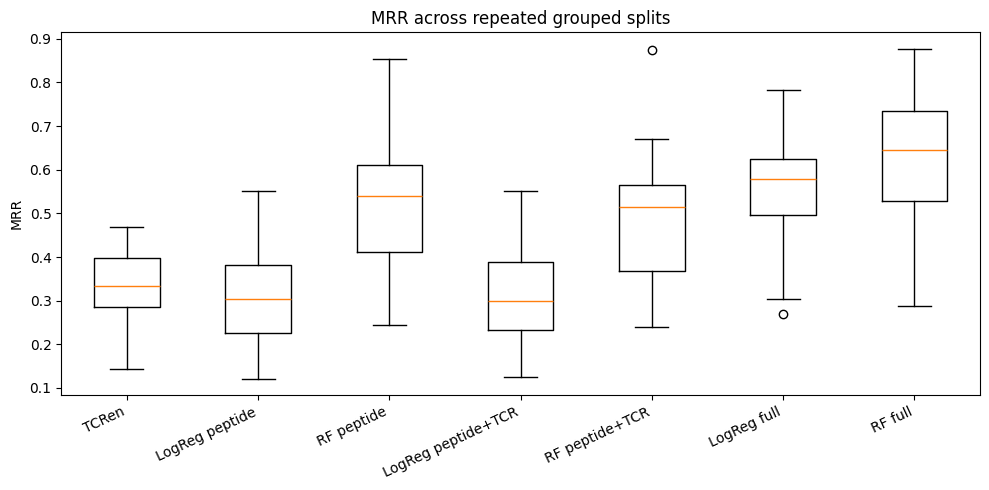

In [5]:
plt.figure(figsize=(10, 5))

data = [results.loc[results["model"] == m, "mrr"].values for m in model_order]

plt.boxplot(data, tick_labels=[label_map[m] for m in model_order])
plt.xticks(rotation=25, ha="right")
plt.ylabel("MRR")
plt.title("MRR across repeated grouped splits")
plt.tight_layout()
plt.show()

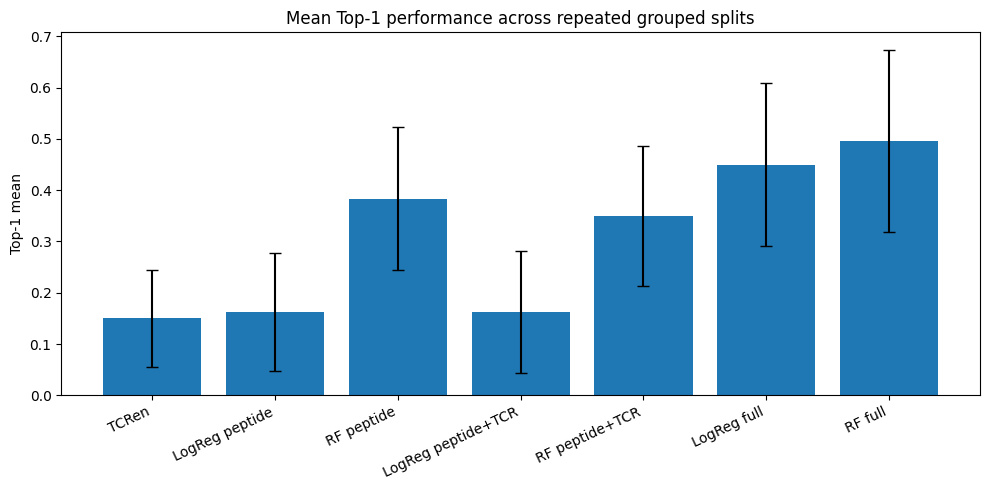

In [6]:
summary2 = summary.set_index("model").loc[model_order].reset_index()

plt.figure(figsize=(10, 5))
plt.bar(
    [label_map[m] for m in summary2["model"]],
    summary2["top1_mean"],
    yerr=summary2["top1_std"],
    capsize=4
)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Top-1 mean")
plt.title("Mean Top-1 performance across repeated grouped splits")
plt.tight_layout()
plt.show()

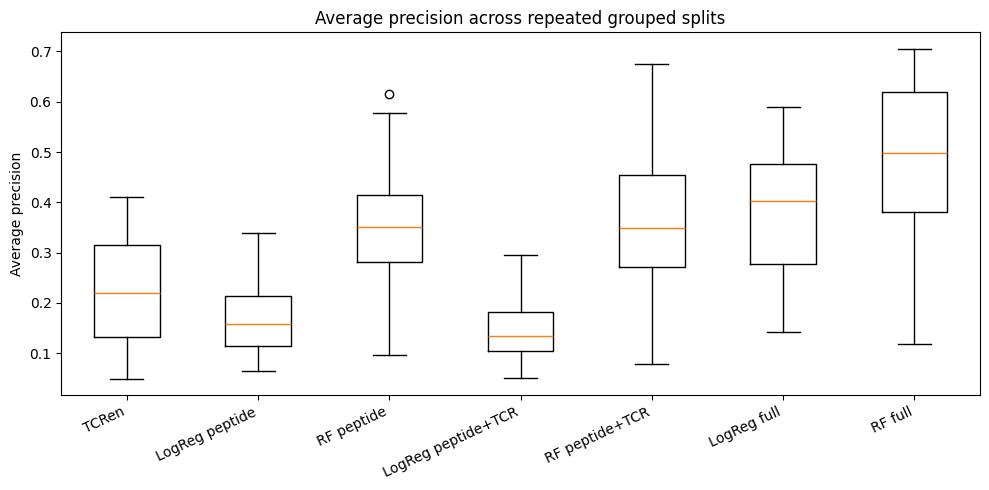

In [7]:
plt.figure(figsize=(10, 5))

data = [results.loc[results["model"] == m, "avg_precision"].values for m in model_order]

plt.boxplot(data, tick_labels=[label_map[m] for m in model_order])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Average precision")
plt.title("Average precision across repeated grouped splits")
plt.tight_layout()
plt.show()

## Interpretation of the results

A few clear patterns appear consistently:

1. **Peptide-only models already outperform the TCRen baseline.**  
   This suggests that simple engineered peptide features contain useful predictive signal.

2. **Adding TCR features improves performance further.**  
   This means explicit TCR sequence information contributes useful information beyond peptide composition alone.

3. **The best results are obtained with the full models.**  
   Combining peptide features, TCR features, and TCRen gives the strongest overall ranking performance.

4. **Random forest performs better than logistic regression against most other models, though not decisively against LogReg full.**  
   A paired statistical significance test (Wilcoxon signed-rank, Holm-Bonferroni corrected — see `src/paired_significance_test.py` and `results/paired_significance_mrr.csv`) confirms RF full's advantage is significant against every other model except LogReg full (p ≈ 0.10, not significant after correction). RF highlights that non-linearity is relevant against the simpler baselines, but isn't decisively better than logistic regression once TCRen is already in the feature set.

See `notebooks/inference_showcase.ipynb` for the model applied to genuinely new input, including a held-out ranking demo.


In [8]:
summary[[
    "model",
    "avg_precision_mean",
    "mrr_mean",
    "top1_mean",
    "top5_mean"
]].sort_values("mrr_mean", ascending=False)

,model,avg_precision_mean,mrr_mean,top1_mean,top5_mean
3,rf_full,0.493498,0.619295,0.495833,0.766667
0,logreg_full,0.370765,0.556221,0.450000,0.700000
4,rf_peptide,0.354508,0.514060,0.383333,0.670833
5,rf_peptide_tcr,0.351293,0.479375,0.350000,0.629167
6,tcren_baseline,0.221983,0.334269,0.150000,0.487500
2,logreg_peptide_tcr,0.147129,0.303491,0.162500,0.458333
1,logreg_peptide,0.166393,0.300919,0.162500,0.466667


## Main conclusion

In this prototype study, the strongest peptide ranking performance was obtained by combining:

- peptide-derived features
- TCR-derived features
- the structure-based TCRen score

The best-performing model was the **RF full** model.

Overall, these results suggest that TCRen is useful as part of a hybrid approach, but that simple learned sequence-derived features can add substantial value.

## Limitations

This is still a small prototype project, so the results should be interpreted with caution.

Main limitations:
- only 25 TCR systems were used
- negative peptides were randomly generated
- candidate peptides were not structurally remodeled
- TCR features were simple engineered summaries rather than richer learned representations

## Possible next steps

Some useful follow-up directions would be:

- use more TCR systems
- generate more realistic negatives by preserving anchor residues
- add richer TCR sequence features
- test additional ranking models
- compare with more baselines

## Reference

This project was built using data derived from the repository accompanying:

**Karnaukhov VK, Shcherbinin DS, Chugunov AO, et al.**  
*Structure-based prediction of T cell receptor recognition of unseen epitopes using TCRen.*  
Nature Computational Science (2024).